In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 1, 2, 4, 3, 4, 0, 1]])

import warnings
warnings.filterwarnings("ignore")

ROOT = "../../../benchmarks/autodiff/CPU_WIP"
b_models = pd.DataFrame()
full_models = pd.DataFrame()

def gather(MODEL):
    global b_models, full_models
    
    PATH = f"{ROOT}/{MODEL.lower()}"
    torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
    torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
    tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

    dfs = [torch2, torch1, tf]

    for df in dfs:
        df.drop(
            columns="Unnamed: 0", inplace=True
        )
        # df.drop(
        #     df[df["pass"] == "Full"].index, inplace=True
        # )

    torch2, torch1, tf = dfs

    for i in [0, 3, 6]:
        torch1.at[i, "item"] = "Torch Script"

    f_base, b_base, fo, bo = [0] * 4
    dfs = [torch2, torch1, tf]

    for df in dfs:
        f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
        b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
        fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
        bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

    f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]
    full_base = f_base + b_base
    fullo = fo + bo

    nabla_df = pd.DataFrame({
        "time": [f_base, b_base, full_base, fo, bo, fullo],
        "pass": ["Forward", "Backward", "Full"] * 2,
        "item": ["Nabla"] * 3 + ["Nabla Optim"] * 3
    }, index=[0] * 6)

    for df in dfs:
        nabla_df = pd.concat([
            nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
        ])

    nabla_df.style.hide(axis="index")
    nabla_df["model"] = MODEL
    f = nabla_df[nabla_df["pass"] == "Forward"]
    b = nabla_df[nabla_df["pass"] == "Backward"]
    full = nabla_df[nabla_df["pass"] == "Full"]
    f["acceleration"] = f_base / f["time"]
    b["acceleration"] = b_base / b["time"]
    full["acceleration"] = full_base / full["time"]

    b_models = pd.concat([b_models, b])
    full_models = pd.concat([full_models, full])

models = [
    "ResNet101",
    "ResNet152",
    "ResNet18",
    "ResNet34",
    "ResNet50",
    "SqueezeNet",
    "VGG11",
    "VGG13",
    "VGG16",
    "VGG19",
]

for model in models:
    gather(model)

    
model = "InceptionV3"
filename = f"{ROOT}/inception/Baseline.csv"
filedata = pd.read_csv(filename)[["time", "pass", "item", "acceleration"]]
filedata["model"] = model
filedata_b = filedata[filedata["pass"] == "Backward"]
filedata_f = filedata[filedata["pass"] == "Full"]
b_models = pd.concat([b_models, filedata_b])
full_models = pd.concat([filedata_f, full_models])

for depth in ["121", "161", "169", "201"]:
    model = f"DenseNet{depth}"
    filename = f"{ROOT}/{model.lower()}/Baseline.csv"
    filedata = pd.read_csv(filename)[["time", "pass", "item", "acceleration"]]
    filedata["model"] = model
    filedata_b = filedata[filedata["pass"] == "Backward"]
    filedata_f = filedata[filedata["pass"] == "Full"]
    b_models = pd.concat([b_models, filedata_b])
    full_models = pd.concat([filedata_f, full_models])

gather("ViT-Base")

fontsize = 18

In [2]:
full_models['item'] = full_models['item'].replace('Nabla', 'JAX')
full_models['item'] = full_models['item'].replace('Nabla Optim', 'SMART')
full_models['item'] = full_models['item'].replace('TensorFlow', 'TF-XLA')
full_models['item'] = full_models['item'].replace('Torch Dynamo', 'TorchDynamo')
full_models['item'] = full_models['item'].replace('Torch Script', 'AutoGrad')

## Backward Pass

## Full Pass

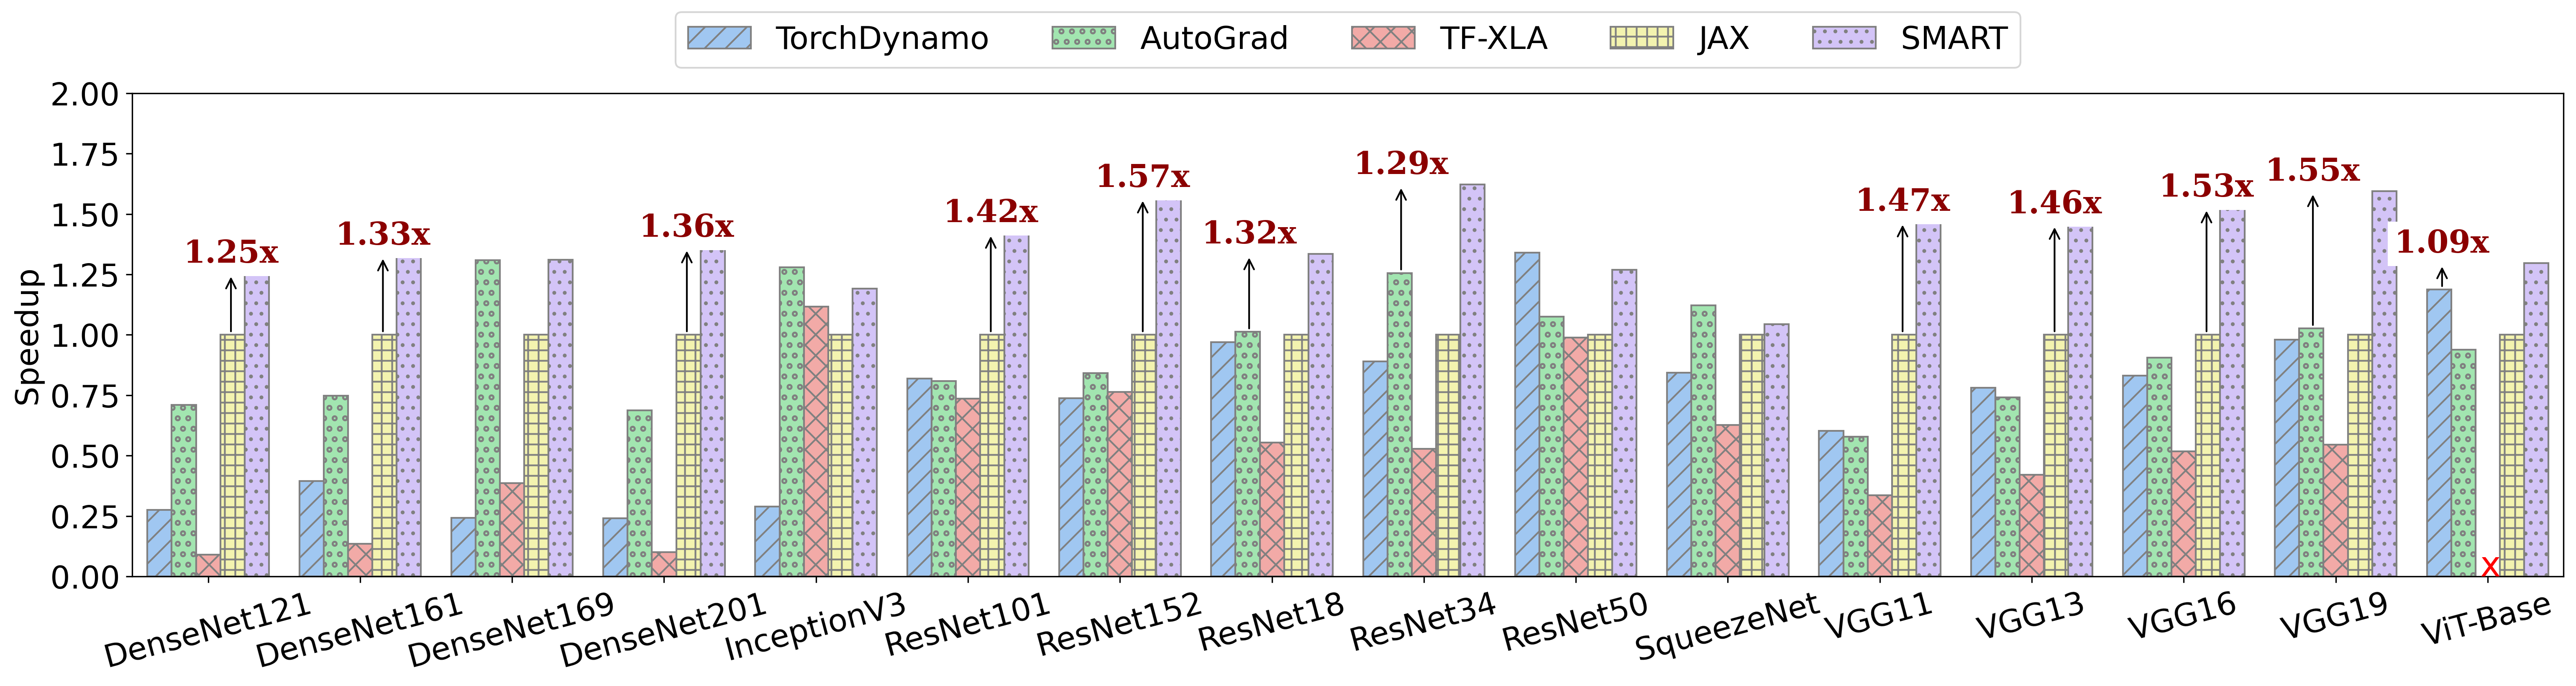

In [3]:
plt.figure(figsize=(25, 5))
plt.rcParams["figure.dpi"] = 300
barplot = sns.barplot(full_models.sort_values(by="model"), x="model", y="acceleration", hue="item", hue_order=["TorchDynamo", "AutoGrad", "TF-XLA", "JAX", "SMART"])

plt.xlabel(None)
plt.ylabel("Speedup", fontsize=fontsize)
plt.xticks(fontsize=fontsize, rotation=15)
plt.yticks(fontsize=fontsize)

plt.ylim([0, 2])
hatches = ["//", "oo", "xx", "++", ".."]

for i, bar in enumerate(barplot.patches):
    bar.set_hatch(hatches[i // len(set(b_models["model"]))])
    bar.set_edgecolor("gray")
    #if (height := bar.get_height()) >= 2:
    #    plt.text(bar.get_x() - 0.1, 2.05, f"{height:.2f}x", color="red", fontsize=fontsize)
plt.text(14.95, 0, "x", color="red", fontsize=20)
fd={ 'size': 18}
ap=dict(facecolor='red', arrowstyle='->', linewidth=1)
start = 1.187197
end = 1.296949
x = 14.7
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.02632
end = 1.595189
x = 13.85
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.52799
x = 13.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.46
x = 12.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.47
x = 11.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.256
end = 1.6217
x = 7.85
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.012
end = 1.334
x = 6.85
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)


start = 1.0
end = 1.569
x = 6.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.423
x = 5.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.3624
x = 3.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.3292
x = 1.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.0
end = 1.255
x = 0.15
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end+0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.2), fontsize=fontsize)
plt.savefig("entire-cpu.pdf", bbox_inches="tight", dpi=300)

In [4]:

pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
print(full_models.sort_values(by="model"))

           time  pass         item  acceleration        model
13  1624.220711  Full       TF-XLA      0.090444  DenseNet121
14   117.070727  Full        SMART      1.254805  DenseNet121
12   206.726860  Full     AutoGrad      0.710604  DenseNet121
11   532.306894  Full  TorchDynamo      0.275970  DenseNet121
10   146.900881  Full          JAX      1.000000  DenseNet121
10   352.065347  Full          JAX      1.000000  DenseNet161
11   892.449185  Full  TorchDynamo      0.394493  DenseNet161
12   470.637229  Full     AutoGrad      0.748061  DenseNet161
13  2599.985840  Full       TF-XLA      0.135410  DenseNet161
14   264.860997  Full        SMART      1.329246  DenseNet161
10   189.658468  Full          JAX      1.000000  DenseNet169
11   780.571932  Full  TorchDynamo      0.242974  DenseNet169
12   144.896069  Full     AutoGrad      1.308928  DenseNet169
13   491.027132  Full       TF-XLA      0.386248  DenseNet169
14   144.668954  Full        SMART      1.310983  DenseNet169
10   253